W Query dynamic range failed. Ret code: RKNN_ERR_MODEL_INVALID. (If it is a static shape RKNN model, please ignore the above warning message.)


YOLO : --> Load YOLO26 model
done
YOLO : --> Init runtime environment YOLO26
I RKNN: [11:18:39.948] RKNN Runtime Information, librknnrt version: 2.4.0 (b458df3b4a@2026-01-17T10:53:35)
I RKNN: [11:18:39.948] RKNN Driver Information, version: 0.9.8
I RKNN: [11:18:39.949] RKNN Model Information, version: 6, toolkit version: 2.3.2(compiler version: 2.3.2 (@2025-04-03T08:26:16)), target: RKNPU v2, target platform: rk3588, framework name: ONNX, framework layout: NCHW, model inference type: static_shape
W RKNN: [11:18:39.960] query RKNN_QUERY_INPUT_DYNAMIC_RANGE error, rknn model is static shape type, please export rknn with dynamic_shapes
done
(320, 320)
YOLO : Inference time: 14.271020889282227 ms


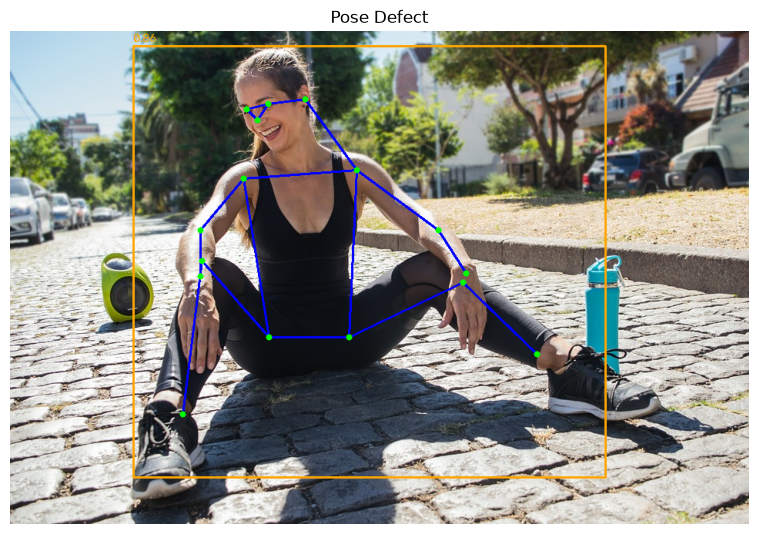

In [1]:
import numpy as np
import cv2
from copy import copy
import platform
from yolo26pose import *
from utils import *
from rknnlite.api import RKNNLite
import time 

RK3588_RKNN_MODEL = './models/pose/yolo26n-pose-RK3588_320_i8.rknn'
IMG_PATH = './images/pose.jpg'
OBJ_THRESH = 0.25
IMG_SIZE = 320
VIEW = True

if __name__ == "__main__":
        yolo = Yolo26Pose(RK3588_RKNN_MODEL)
        print( detect_imgsz_from_path(RK3588_RKNN_MODEL))
        objects = yolo(IMG_PATH)

        if VIEW:
                yolo.draw(objects)
                plt_img_show(yolo.img_result, "Pose Defect", percent=100)
                #cv2.imshow("post process result", yolo.img_result)
                #cv2.waitKey(0)
                #cv2.destroyAllWindows()

        #show_rgb_image(img_org, 'post process result')

        yolo.release()